# EDA — 탐색적 데이터 분석
## 지정학적 위기 시 비트코인은 디지털 금인가?

> 상세 내용은 [README.md](README.md) 참조


---
## Step 0. 환경 설정


In [1]:
# !pip install yfinance pandas numpy matplotlib seaborn scipy statsmodels --quiet

import warnings
warnings.filterwarnings('ignore')

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import het_arch

# 한글 폰트 설정
# plt.rcParams['font.family'] = 'Malgun Gothic'   # Windows
plt.rcParams['font.family'] = 'AppleGothic'  # Mac
# 구글 Colab:
# !apt-get install -y fonts-nanum > /dev/null
# plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 150

# 전역 상수
TICKERS = {
    'BTC'   : 'BTC-USD',
    'Gold'  : 'GC=F',
    'TLT'   : 'TLT',
    'DXY'   : 'DX-Y.NYB',
    'SP500' : '^GSPC',
    'NASDAQ': '^IXIC',
}

COLORS = {
    'BTC'   :'#F7931A', 'Gold':'#FFD700', 'TLT':'#2196F3',
    'DXY'   :'#9C27B0', 'SP500':'#F44336', 'NASDAQ':'#E91E63'
}
STYLES = {
    'BTC':(2.5,'-'), 'Gold':(1.8,'-'), 'TLT':(1.8,'-'),
    'DXY':(1.8,'--'), 'SP500':(1.5,'-.'), 'NASDAQ':(1.5,':')
}

# 이란 전쟁 이벤트 마커
EVENTS = {
    '시위 시작\n(2025-12-01)' : '2025-12-01',
    '항모 배치\n(2026-01-15)' : '2026-01-15',
    '공습 시작\n(2026-02-28)' : '2026-02-28',
}

# 5개 이벤트 타임라인
EVENT_PERIODS = {
    'US_Iran_Conflict'  : {'start':'2019-07-01','end':'2020-07-01','event_date':'2020-01-03'},
    'COVID19_Pandemic'  : {'start':'2019-09-01','end':'2020-09-01','event_date':'2020-03-11'},
    'Russia_Ukraine_War': {'start':'2021-08-01','end':'2022-08-01','event_date':'2022-02-24'},
    'Israel_Hamas_War'  : {'start':'2023-04-01','end':'2024-04-01','event_date':'2023-10-07'},
    'Iran_War'          : {'start':'2025-06-01','end':'2026-03-24','event_date':'2026-02-28'},
}

WAR_START = '2026-02-28'   # 이란 전쟁 전/후 구분 기준일
print('환경 설정 완료')

환경 설정 완료


---
## Step 1. 데이터 수집 및 정제

- 수집 기간: 2019-07-01 ~ 2026-03-24
- 결측치: NASDAQ 거래일 기준 정렬 후 ffill


In [2]:
global_start = min(v['start'] for v in EVENT_PERIODS.values())
global_end   = max(v['end']   for v in EVENT_PERIODS.values())
print(f'수집 기간: {global_start} ~ {global_end}')

raw = yf.download(
    list(TICKERS.values()),
    start=global_start,
    end=global_end,
    auto_adjust=False,
    progress=False
)['Close']
raw.columns = list(TICKERS.keys())

# NYSE 거래일 기준 정렬 + ffill
df = raw.dropna(subset=['SP500','NASDAQ'])
df = df.ffill()

print(f'\n▶ 결측치 확인:')
print(df.isnull().sum())
print(f'\n▶ 총 거래일: {len(df)}일')
df.tail(3)

수집 기간: 2019-07-01 ~ 2026-03-24

▶ 결측치 확인:
BTC       0
Gold      0
TLT       0
DXY       0
SP500     0
NASDAQ    0
dtype: int64

▶ 총 거래일: 1691일


,BTC,Gold,TLT,DXY,SP500,NASDAQ
Date,,,,,,
2026-03-19,69912.789062,99.230003,4600.700195,87.489998,6606.490234,22090.689453
2026-03-20,70522.585938,99.650002,4570.399902,85.830002,6506.479980,21647.609375
2026-03-23,70914.859375,98.949997,4404.100098,86.389999,6581.000000,21946.759766


In [3]:
# 로그 수익률
returns    = np.log(df / df.shift(1)).dropna()
normalized = df / df.iloc[0] * 100

df.to_csv('prices.csv',     encoding='utf-8-sig')
returns.to_csv('returns.csv',    encoding='utf-8-sig')
normalized.to_csv('normalized.csv', encoding='utf-8-sig')

# 이벤트별 데이터 슬라이싱 함수
def get_event_data(event_name, event_info):
    start      = event_info['start']
    end        = event_info['end']
    event_date = pd.to_datetime(event_info['event_date'])
    ec = df.loc[start:end].copy()
    er = returns.loc[start:end].copy()
    en = ec / ec.iloc[0]
    return {
        'event_close'     : ec,
        'event_returns'   : er,
        'event_normalized': en,
        'before_returns'  : er[er.index <  event_date],
        'after_returns'   : er[er.index >= event_date],
        'event_date'      : event_date,
    }

print(' 데이터 수집 완료 / get_event_data() 정의 완료')

 데이터 수집 완료 / get_event_data() 정의 완료


---
## Step 2. 기술통계

연환산 수익률·변동성·왜도·첨도·샤프지수 산출


In [4]:
RISK_FREE    = 0.04 / 252
TRADING_DAYS = 252

rows = []
for col in returns.columns:
    r = returns[col].dropna()
    rows.append({
        '자산'           : col,
        '평균수익률(연,%)': round(r.mean() * TRADING_DAYS * 100, 2),
        '변동성(연,%)'   : round(r.std()  * np.sqrt(TRADING_DAYS) * 100, 2),
        '왜도'           : round(r.skew(), 3),
        '첨도'           : round(r.kurt(), 3),
        '샤프지수'        : round((r.mean()-RISK_FREE)/r.std()*np.sqrt(TRADING_DAYS), 3),
        '최솟값(%)'      : round(r.min()*100, 2),
        '최댓값(%)'      : round(r.max()*100, 2),
    })

stats_df = pd.DataFrame(rows).set_index('자산')
display(stats_df)

print('\n▶ 해석:')
for col in returns.columns:
    k = returns[col].kurt()
    s = returns[col].skew()
    v = returns[col].std() * np.sqrt(TRADING_DAYS) * 100
    print(f'  [{col}] 변동성 {v:.1f}%  '
          f'첨도 {k:.2f}{" → GARCH 근거 ✅" if k>3 else ""}  '
          f'왜도 {s:.2f}{" (하락충격큼)" if s<0 else ""}')

,"평균수익률(연,%)","변동성(연,%)",왜도,첨도,샤프지수,최솟값(%),최댓값(%)
자산,,,,,,,
BTC,28.36,62.60,-1.051,14.608,0.389,-46.47,19.15
Gold,0.32,6.91,-0.205,1.760,-0.532,-2.14,1.64
TLT,17.24,18.13,-1.006,10.535,0.730,-12.07,5.91
DXY,-6.35,16.72,0.064,4.238,-0.619,-6.90,7.25
SP500,11.89,20.24,-0.661,15.289,0.390,-12.77,9.09
NASDAQ,14.88,24.45,-0.423,8.210,0.445,-13.15,11.48



▶ 해석:
  [BTC] 변동성 62.6%  첨도 14.61 → GARCH 근거 ✅  왜도 -1.05 (하락충격큼)
  [Gold] 변동성 6.9%  첨도 1.76  왜도 -0.21 (하락충격큼)
  [TLT] 변동성 18.1%  첨도 10.53 → GARCH 근거 ✅  왜도 -1.01 (하락충격큼)
  [DXY] 변동성 16.7%  첨도 4.24 → GARCH 근거 ✅  왜도 0.06
  [SP500] 변동성 20.2%  첨도 15.29 → GARCH 근거 ✅  왜도 -0.66 (하락충격큼)
  [NASDAQ] 변동성 24.5%  첨도 8.21 → GARCH 근거 ✅  왜도 -0.42 (하락충격큼)


---
## Step 3-1. 전체 기간 가격 추이


In [ ]:
fig, ax = plt.subplots(figsize=(15,7))

for col in normalized.columns:
    lw, ls = STYLES[col]
    ax.plot(normalized.index, normalized[col],
            label=col, color=COLORS[col], linewidth=lw, linestyle=ls)

for name, date in EVENTS.items():
    ts = pd.Timestamp(date)
    if ts >= normalized.index.min():
        ax.axvline(ts, color='red', linestyle='--', alpha=0.8, linewidth=1.2)
        ax.text(ts, normalized.max().max()*1.01, name,
                fontsize=8, color='red', ha='center', va='bottom')

war_ts = pd.Timestamp(WAR_START)
if war_ts <= normalized.index.max():
    ax.axvspan(war_ts, normalized.index.max(),
               alpha=0.08, color='red', label='전쟁 기간')

ax.set_title('자산별 가격 추이 (수집 시작일 = 100 기준)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('상대 가격 지수')
ax.legend(loc='upper left', fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('plot1_price_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('▶ plot1_price_trend.png 저장')

---
## Step 3-2. 이벤트별 정규화 가격 비교


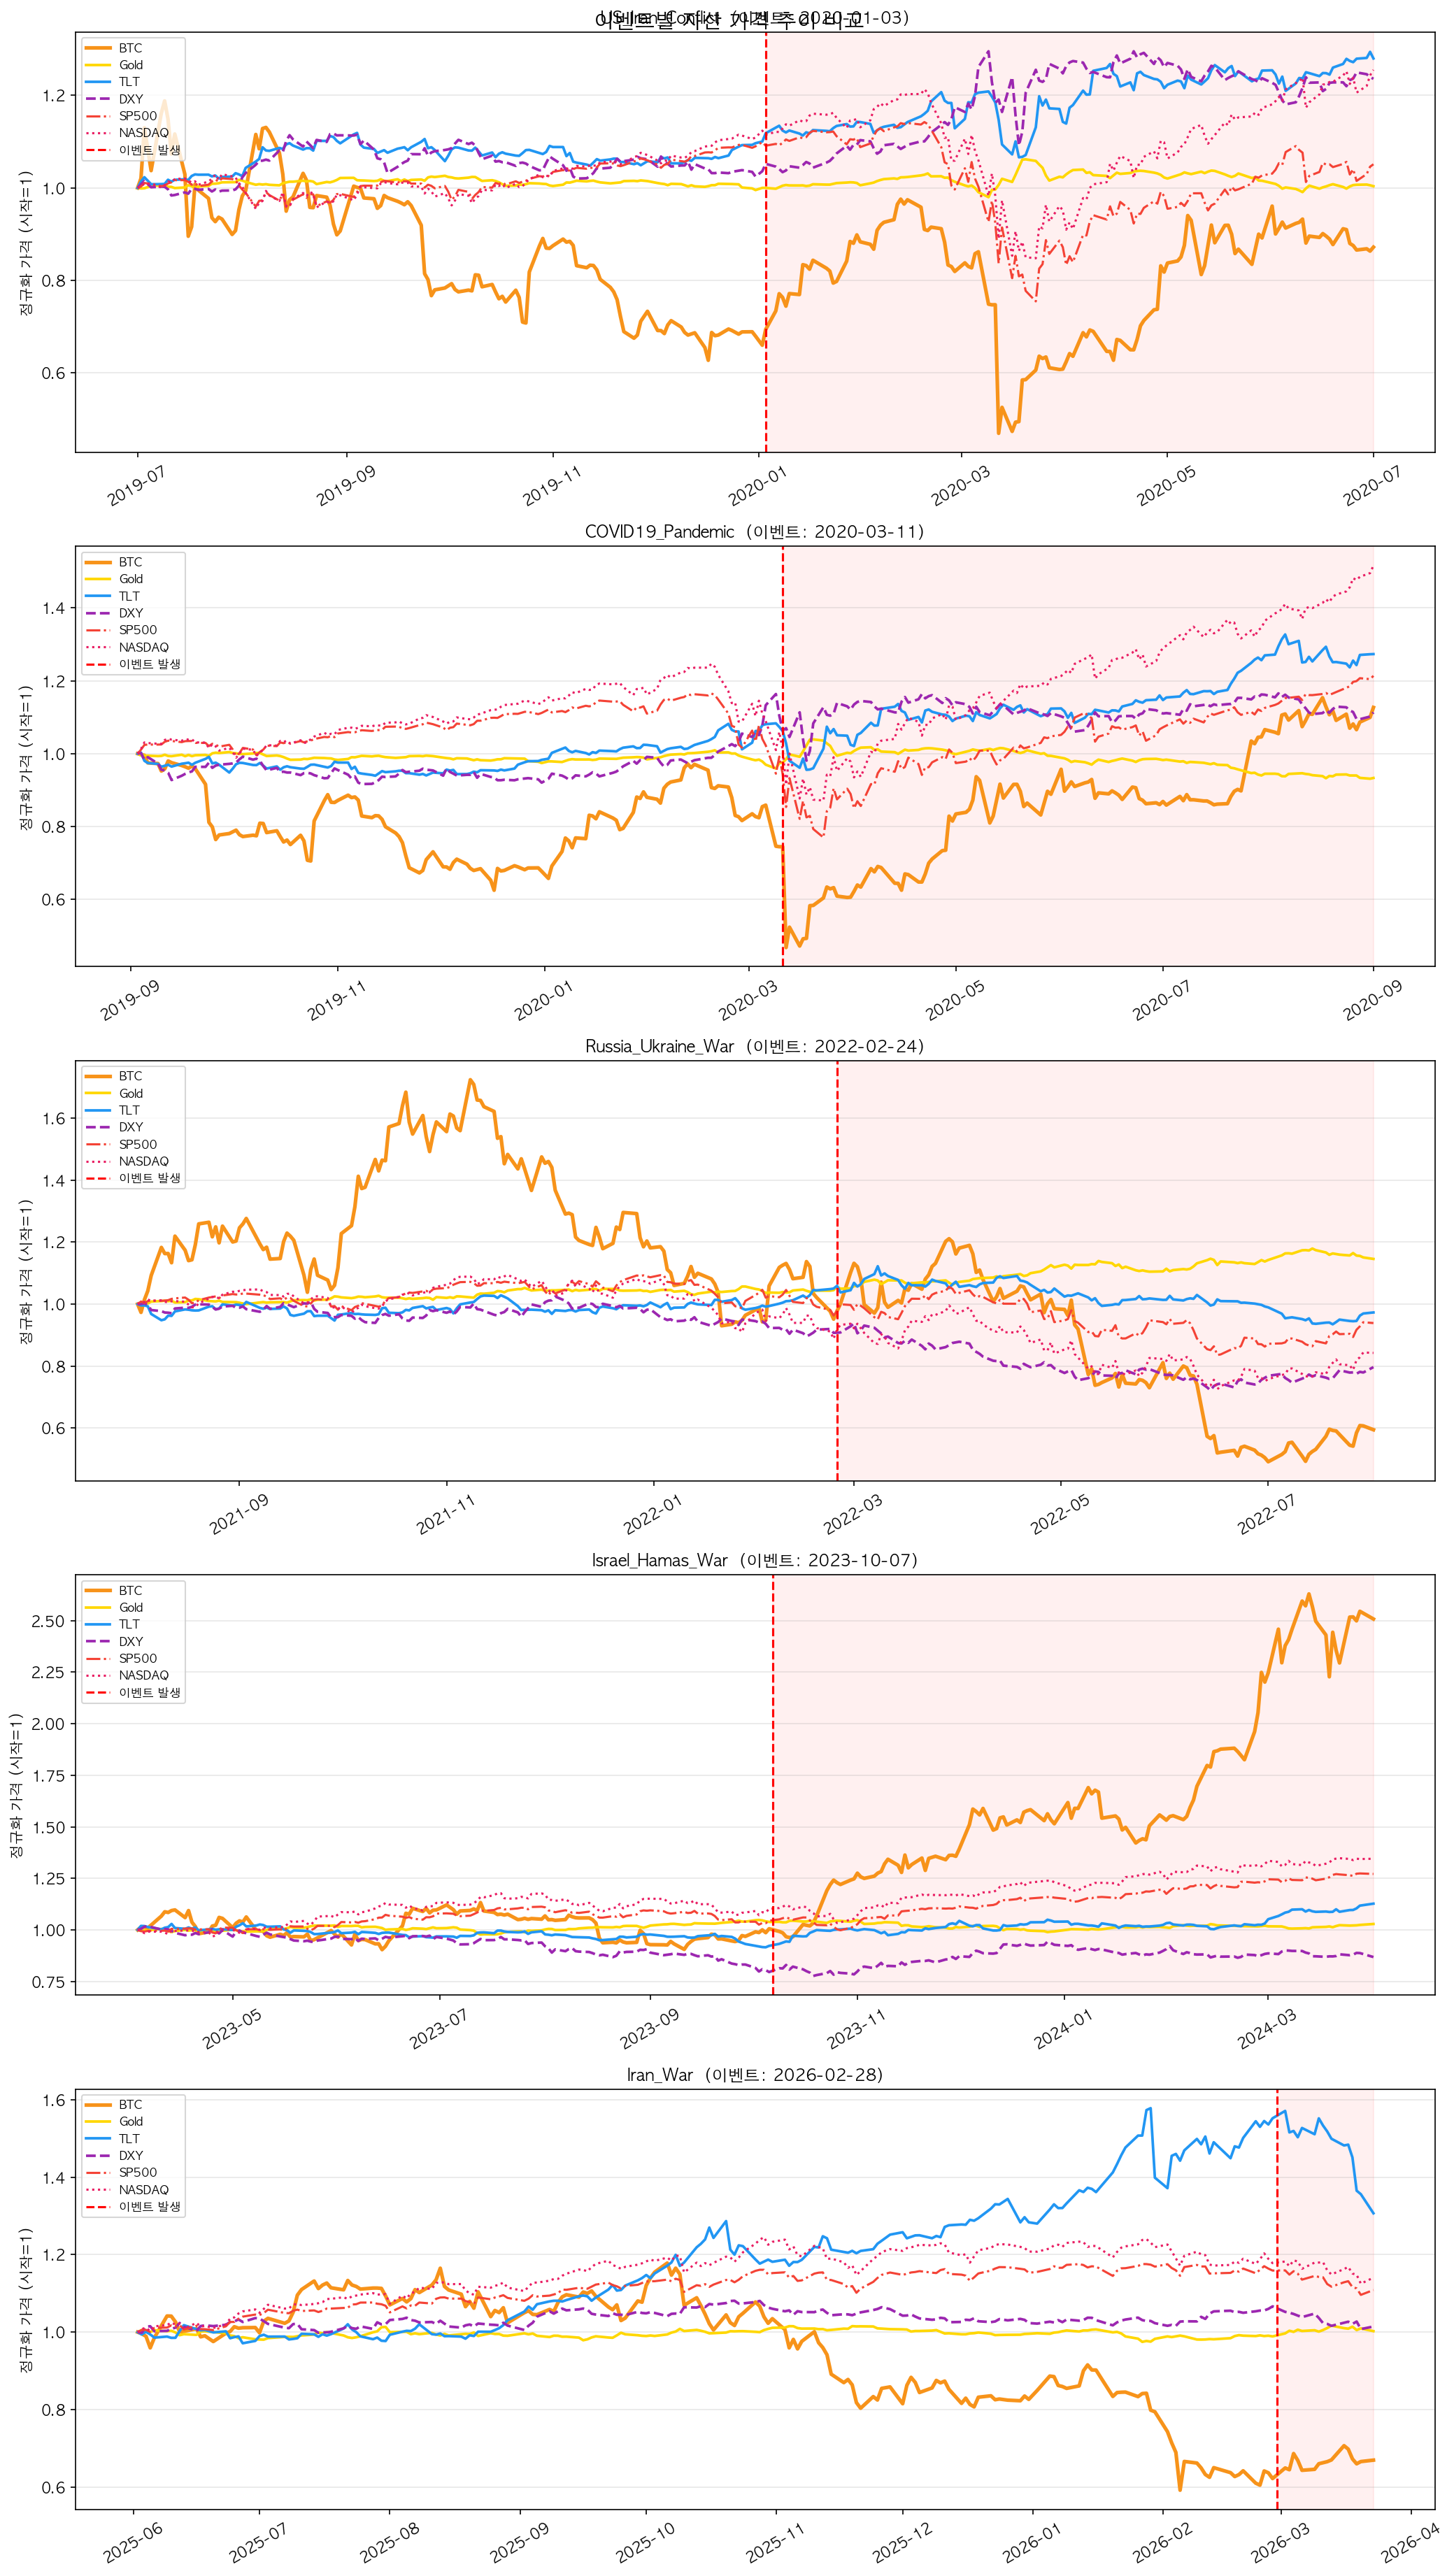

▶ plot2_event_price.png 저장


In [6]:
fig, axes = plt.subplots(
    len(EVENT_PERIODS),
    1,
    figsize=(14, 5 * len(EVENT_PERIODS))
)

for ax, (event_name, event_info) in zip(axes, EVENT_PERIODS.items()):

    data  = get_event_data(event_name, event_info)
    en    = data['event_normalized']
    edate = data['event_date']

    for col in en.columns:

        lw, ls = STYLES[col]

        ax.plot(
            en.index,
            en[col],
            label=col,
            color=COLORS[col],
            linewidth=lw,
            linestyle=ls
        )

    if edate >= en.index.min():

        ax.axvline(
            edate,
            color='red',
            linestyle='--',
            linewidth=1.5,
            label='이벤트 발생'
        )

        ax.axvspan(
            edate,
            en.index.max(),
            alpha=0.06,
            color='red'
        )

    ax.set_title(
        f'{event_name}  (Event: {edate.date()})',
        fontsize=10,
        fontweight='bold',
        pad=12          # ← 제목 아래 여백 추가
    )

    ax.set_ylabel('정규화 가격 (시작=1)')

    ax.legend(
        fontsize=8,
        loc='upper left'
    )

    ax.grid(
        axis='y',
        alpha=0.3
    )

    ax.xaxis.set_major_formatter(
        mdates.DateFormatter('%Y-%m')
    )

    plt.setp(
        ax.xaxis.get_majorticklabels(),
        rotation=30
    )

fig.suptitle(
    '이벤트별 자산 가격 추이 비교',
    fontsize=16,
    fontweight='bold',
    y=0.995     
)

plt.tight_layout(
    rect=[0, 0, 1, 0.98] 
)

plt.savefig(
    'plot2_event_price.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print('▶ plot2_event_price.png 저장')

---
## Step 3-3. 이동평균선 MA20·MA60


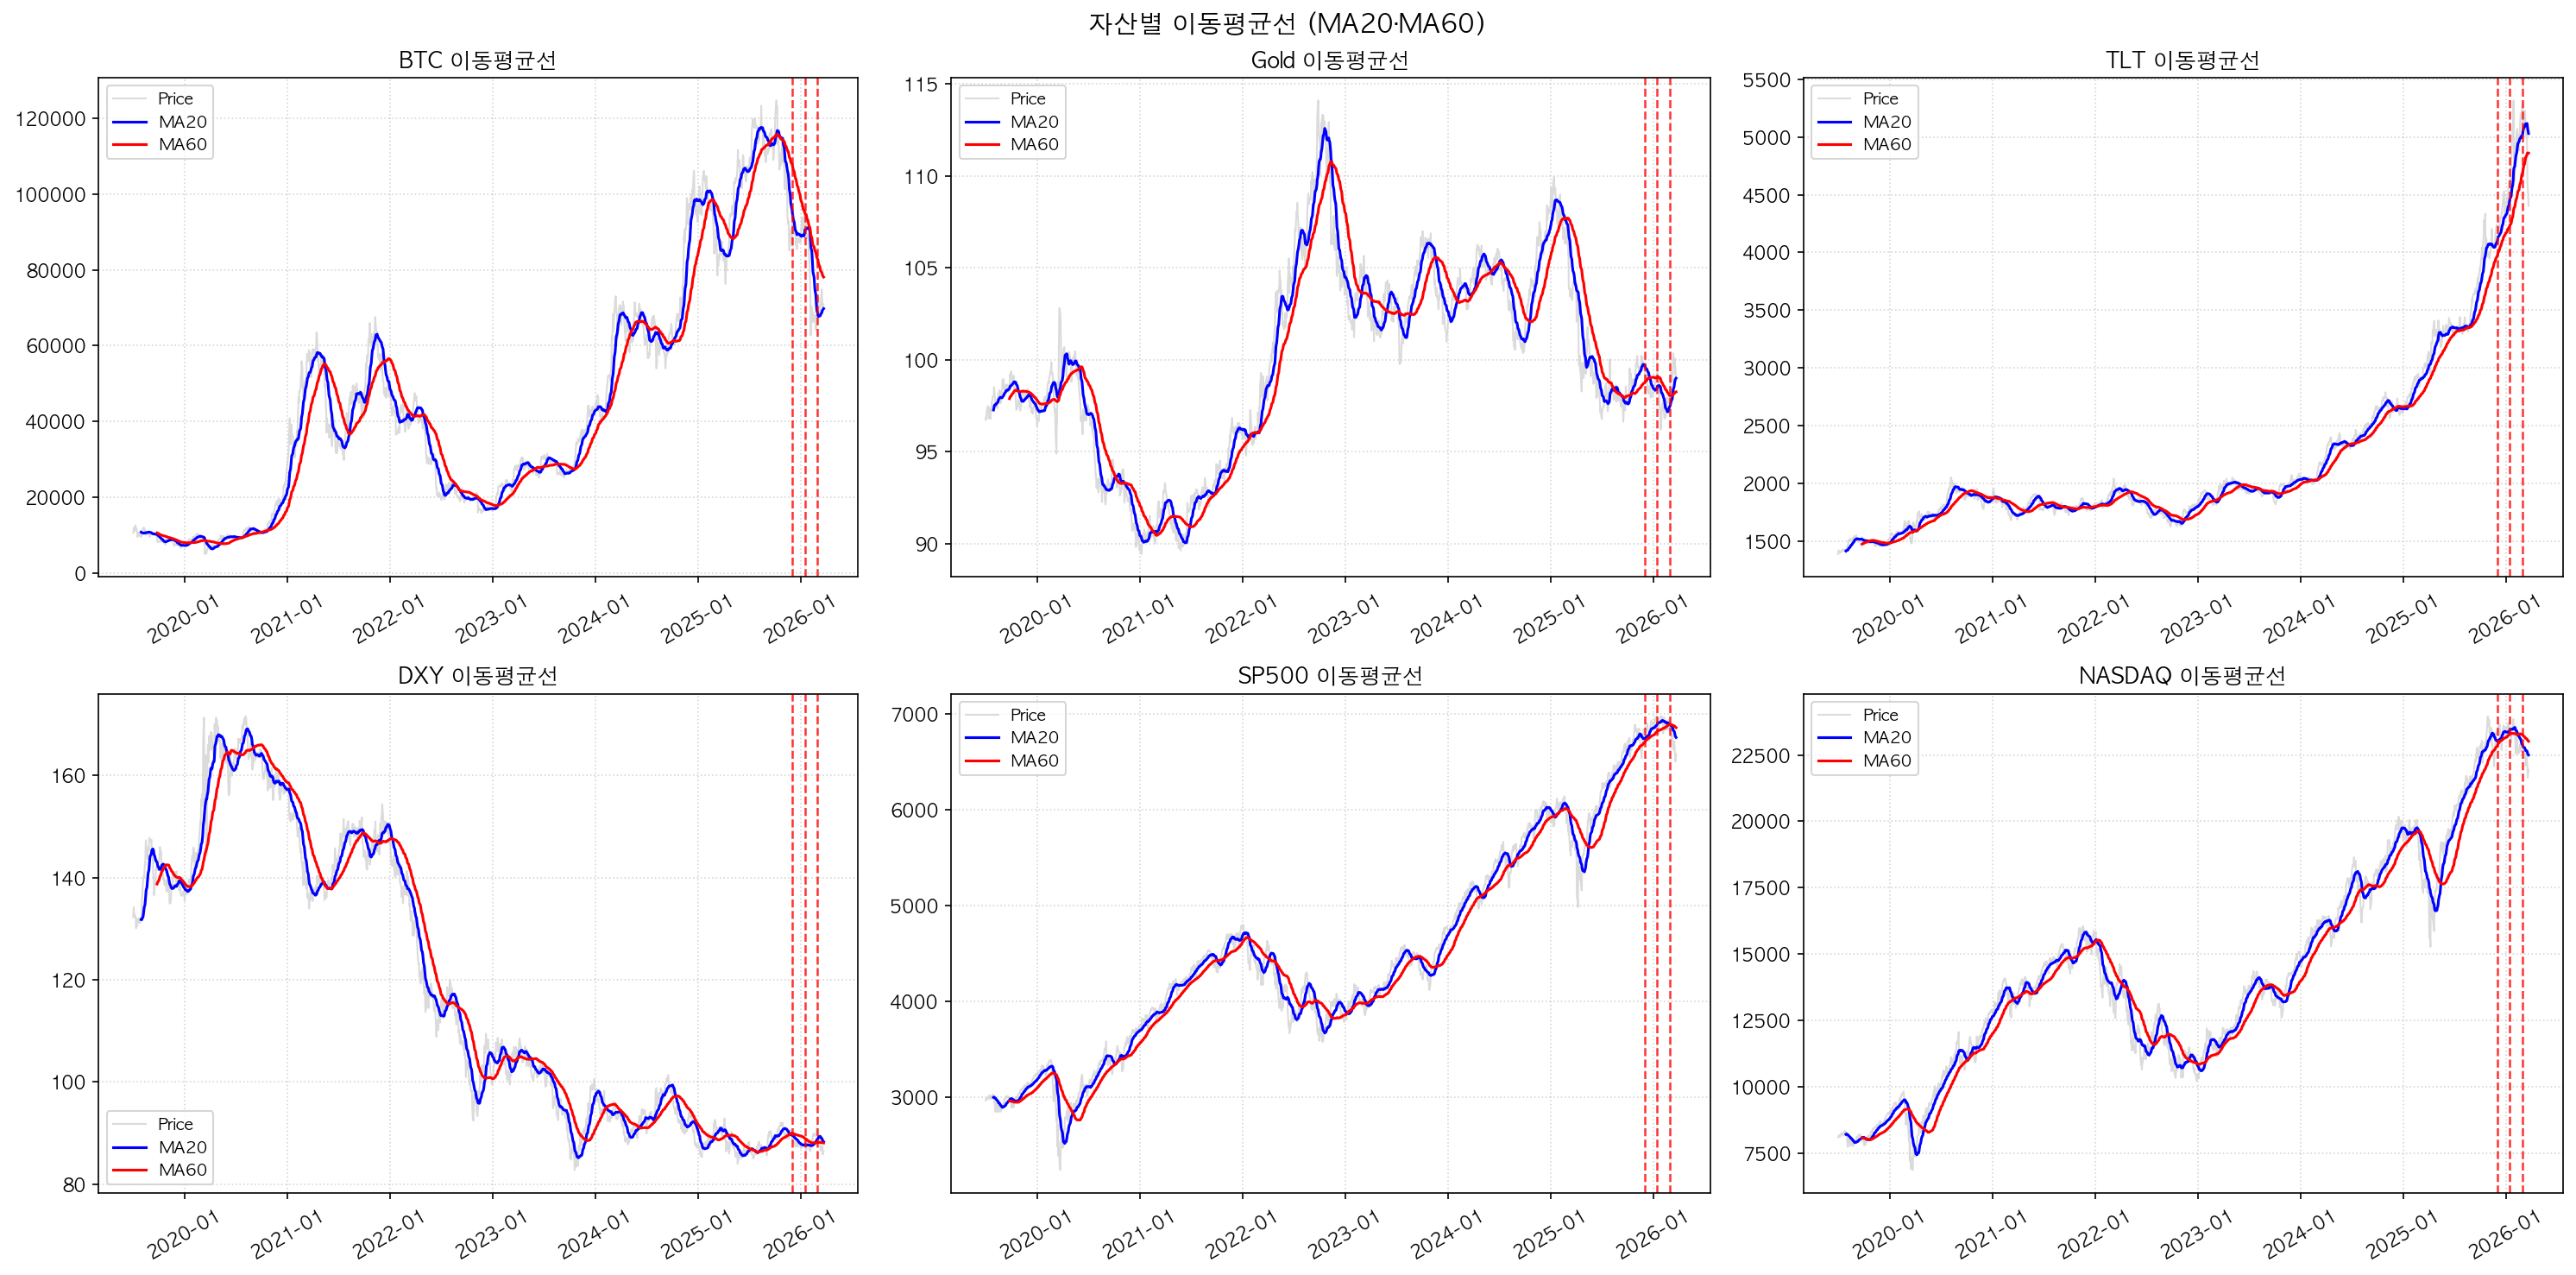

▶ plot3_moving_average.png 저장


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes_flat = axes.flatten()

for i, col in enumerate(df.columns):
    ax  = axes_flat[i]
    s   = df[col].dropna()
    ma20 = s.rolling(20).mean()
    ma60 = s.rolling(60).mean()

    ax.plot(s.index, s,    color='lightgray', linewidth=1,   alpha=0.8, label='Price')
    ax.plot(ma20.index, ma20, color='blue',  linewidth=1.5, label='MA20')
    ax.plot(ma60.index, ma60, color='red',   linewidth=1.5, label='MA60')

    # 이벤트 마커
    for name, date in EVENTS.items():
        ts = pd.Timestamp(date)
        if s.index.min() <= ts <= s.index.max():
            ax.axvline(ts, color='red', linestyle='--',
                       linewidth=1.2, alpha=0.8)

    ax.set_title(f'{col} 이동평균선', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

fig.suptitle('자산별 이동평균선 (MA20·MA60)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot3_moving_average.png', dpi=150, bbox_inches='tight')
plt.show()
print('▶ plot3_moving_average.png 저장')

---
## Step 4-1. 수익률 분포 + 변동성 군집


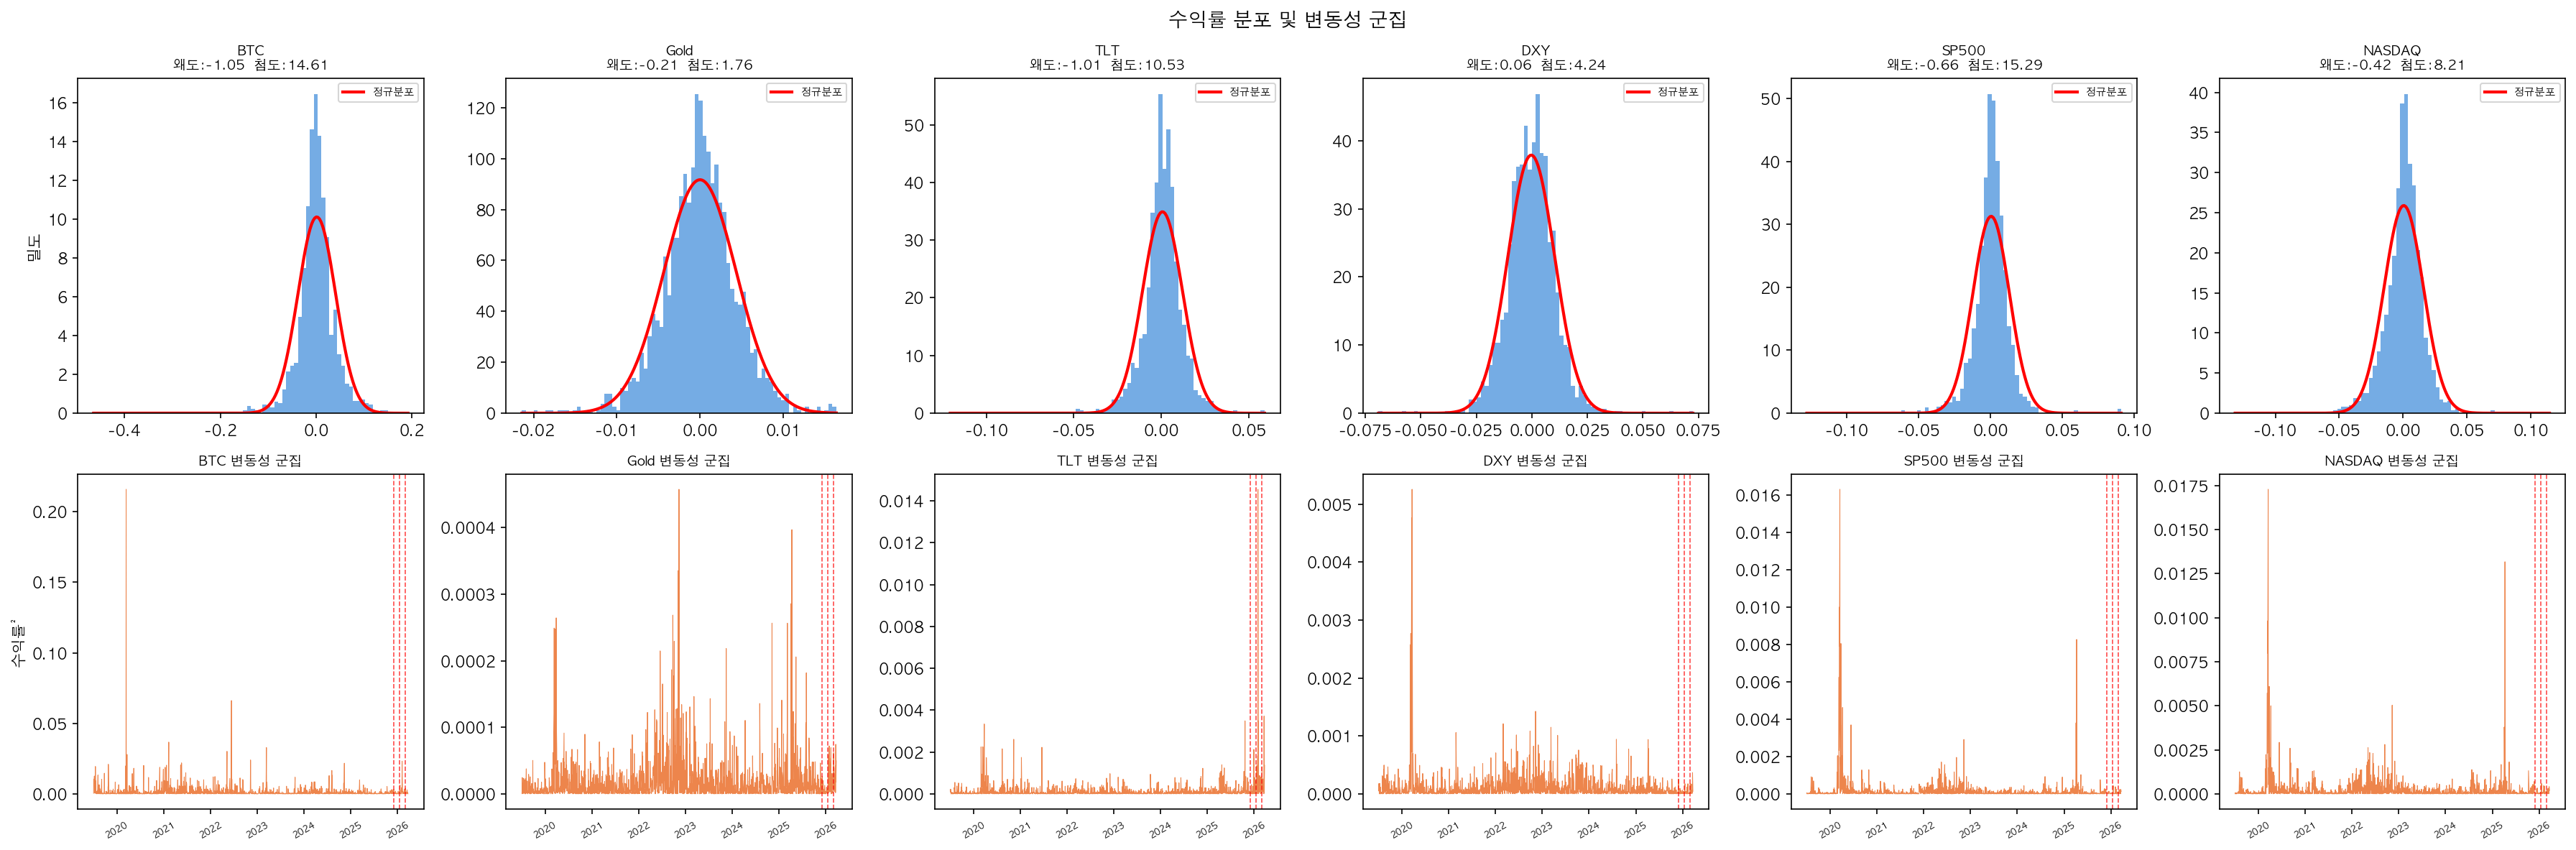

▶ plot4_returns_dist.png 저장


In [8]:
cols = list(returns.columns)
n    = len(cols)
fig, axes = plt.subplots(2, n, figsize=(4*n, 8))

for i, col in enumerate(cols):
    r = returns[col].dropna()

    # 상단: 히스토그램 + 정규분포
    ax1 = axes[0][i]
    ax1.hist(r, bins=80, density=True, alpha=0.6,
             color='#1976D2', edgecolor='none')
    x = np.linspace(r.min(), r.max(), 200)
    ax1.plot(x, stats.norm.pdf(x, r.mean(), r.std()),
             'r-', linewidth=2, label='정규분포')
    ax1.set_title(f'{col}\n왜도:{r.skew():.2f}  첨도:{r.kurt():.2f}',
                  fontsize=9)
    ax1.legend(fontsize=7)

    # 하단: 변동성 군집
    ax2 = axes[1][i]
    ax2.plot(returns.index, returns[col]**2,
             linewidth=0.5, color='#E65100', alpha=0.7)
    for name, date in EVENTS.items():
        ts = pd.Timestamp(date)
        if ts >= returns.index.min():
            ax2.axvline(ts, color='red', linestyle='--',
                        alpha=0.7, linewidth=0.8)
    ax2.set_title(f'{col} 변동성 군집', fontsize=9)
    ax2.tick_params(axis='x', rotation=30, labelsize=6)

axes[0][0].set_ylabel('밀도')
axes[1][0].set_ylabel('수익률²')
fig.suptitle('수익률 분포 및 변동성 군집',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot4_returns_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print('▶ plot4_returns_dist.png 저장')

---
## Step 4-2. BTC High-Low 일별 변동폭


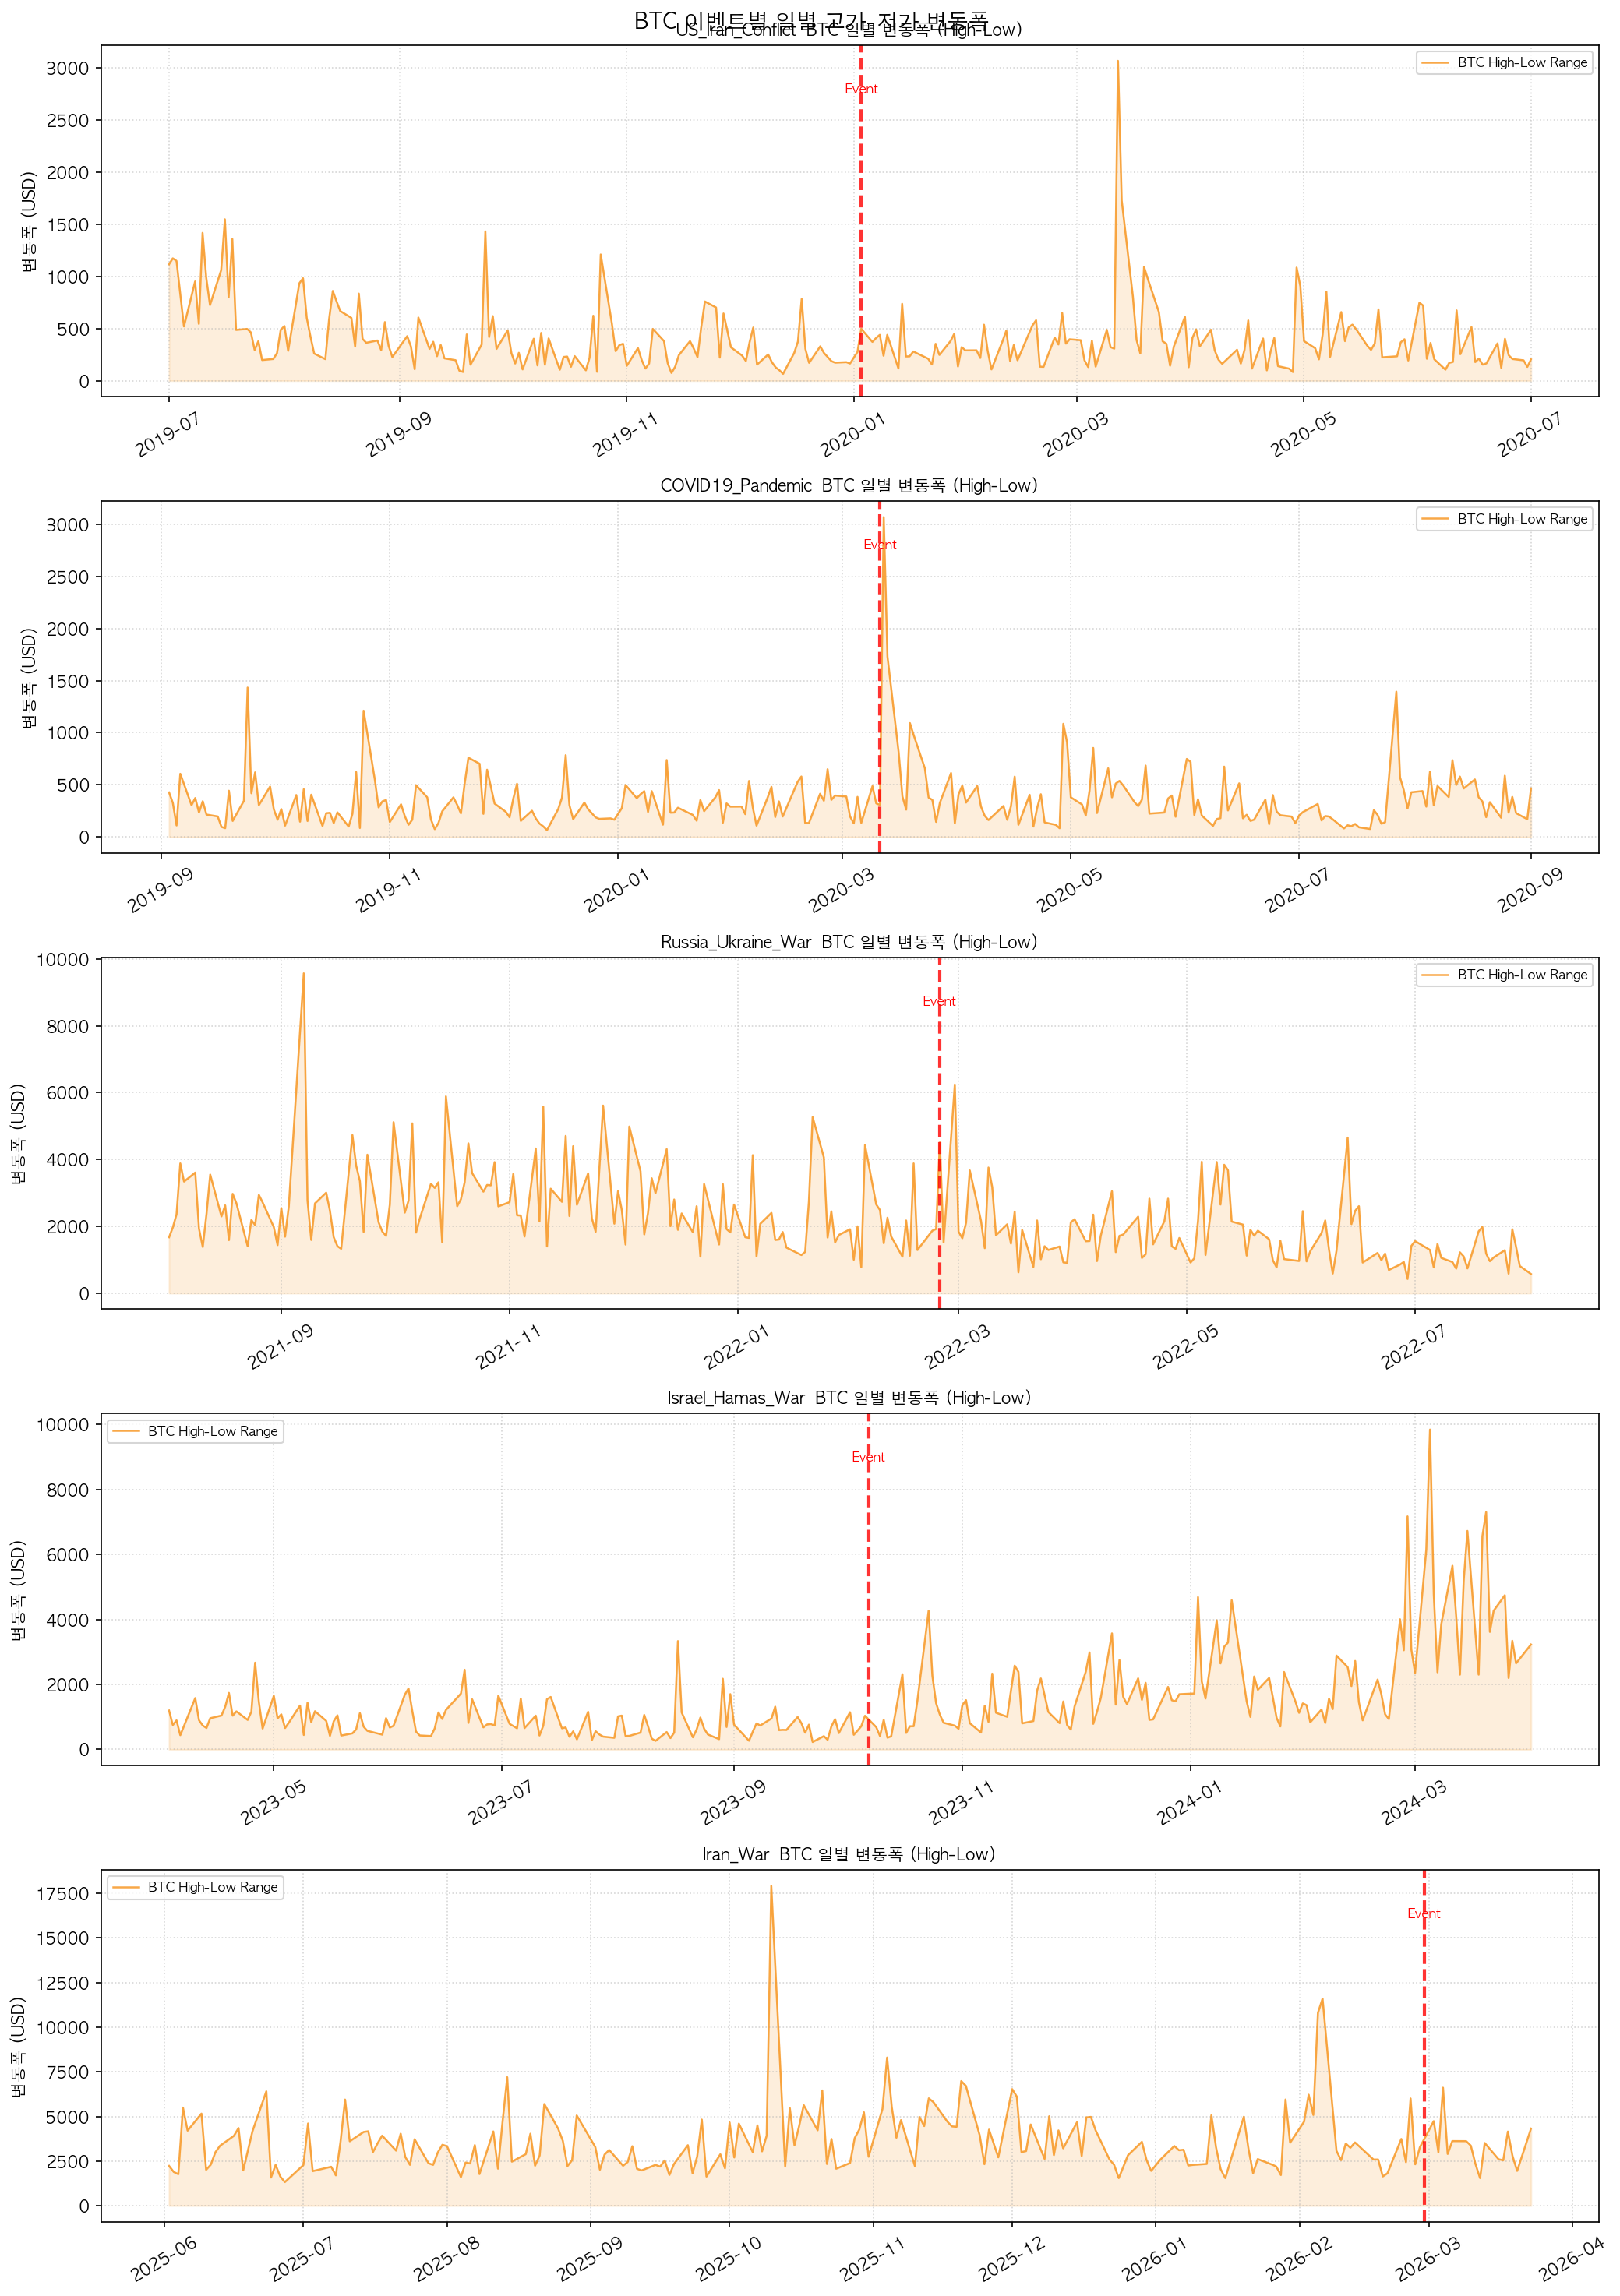

▶ plot5_btc_highlow.png 저장


In [9]:
raw_ohlcv = yf.download(
    'BTC-USD',
    start=global_start,
    end=global_end,
    auto_adjust=False,
    progress=False
)

raw_ohlcv.index = pd.to_datetime(raw_ohlcv.index.date)
raw_ohlcv = raw_ohlcv.reindex(df.index)

high = raw_ohlcv['High'].squeeze()
low  = raw_ohlcv['Low'].squeeze()

daily_range = high - low


fig, axes = plt.subplots(
    len(EVENT_PERIODS),
    1,
    figsize=(14, 4 * len(EVENT_PERIODS)),
    sharex=False
)

if len(EVENT_PERIODS) == 1:
    axes = [axes]


for ax, (event_name, event_info) in zip(axes, EVENT_PERIODS.items()):

    start      = event_info['start']
    end        = event_info['end']

    event_date = pd.to_datetime(
        event_info['event_date']
    )

    seg = daily_range.loc[start:end].dropna()


    ax.plot(
        seg.index,
        seg,
        color='#F7931A',
        linewidth=1.2,
        alpha=0.8,
        label='BTC High-Low Range'
    )

    ax.fill_between(
        seg.index,
        seg,
        alpha=0.15,
        color='#F7931A'
    )

    if seg.index.min() <= event_date <= seg.index.max():

        ax.axvline(
            event_date,
            color='red',
            linestyle='--',
            linewidth=2,
            alpha=0.8
        )

        ax.text(
            event_date,
            seg.max() * 0.9,
            'Event',
            color='red',
            fontweight='bold',
            ha='center',
            fontsize=8
        )


    ax.set_title(
        f'{event_name}  BTC 일별 변동폭 (High-Low)',
        fontsize=10,
        fontweight='bold',
        pad=12       
    )

    ax.set_ylabel(
        '변동폭 (USD)'
    )

    ax.legend(
        fontsize=8
    )

    ax.grid(
        True,
        linestyle=':',
        alpha=0.5
    )

    ax.xaxis.set_major_formatter(
        mdates.DateFormatter('%Y-%m')
    )

    plt.setp(
        ax.xaxis.get_majorticklabels(),
        rotation=30
    )


fig.suptitle(
    'BTC 이벤트별 일별 고가-저가 변동폭',
    fontsize=14,
    fontweight='bold',
    y=0.995      
)


plt.tight_layout(
    rect=[0, 0, 1, 0.98] 
)

plt.savefig(
    'plot5_btc_highlow.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print('▶ plot5_btc_highlow.png 저장')

---
## Step 5. 통계 검정

| 검정 | p < 0.05 의미 |
|------|---------------|
| Jarque-Bera | 정규분포 아님 → 비선형 모델 필요 |
| ADF | 정상성 확인 → 시계열 분석 가능 |
| ARCH | 변동성 군집 → GARCH 사용 정당화 |


In [10]:
results = []
for col in returns.columns:
    r = returns[col].dropna()
    jb_stat, jb_p          = stats.jarque_bera(r)
    adf_p                  = adfuller(r, autolag='AIC')[1]
    arch_stat, arch_p, _, _ = het_arch(r, nlags=5)
    results.append({
        '자산'         : col,
        'JB p-value'  : round(jb_p,   4),
        '정규분포 여부': '❌ 아님'   if jb_p   < 0.05 else '✅ 정규분포',
        'ADF p-value' : round(adf_p,  4),
        '정상성'       : '✅ 정상'   if adf_p  < 0.05 else '❌ 비정상',
        'ARCH p-value': round(arch_p, 4),
        'GARCH 사용'  : '✅ 정당화' if arch_p < 0.05 else '❌ 효과 없음',
    })

test_df = pd.DataFrame(results).set_index('자산')
display(test_df)

print('\n▶ 핵심 해석:')
print('  JB  p<0.05 → 정규분포 아님  → 첨도·왜도 큰 금융 분포')
print('  ADF p<0.05 → 정상성 확인   → 시계열 모델 적용 가능')
print('  ARCH p<0.05→ 변동성 군집   → GARCH 모델 사용 정당화 ✅')

,JB p-value,정규분포 여부,ADF p-value,정상성,ARCH p-value,GARCH 사용
자산,,,,,,
BTC,0.0,❌ 아님,0.0,✅ 정상,0.0,✅ 정당화
Gold,0.0,❌ 아님,0.0,✅ 정상,0.0,✅ 정당화
TLT,0.0,❌ 아님,0.0,✅ 정상,0.0,✅ 정당화
DXY,0.0,❌ 아님,0.0,✅ 정상,0.0,✅ 정당화
SP500,0.0,❌ 아님,0.0,✅ 정상,0.0,✅ 정당화
NASDAQ,0.0,❌ 아님,0.0,✅ 정상,0.0,✅ 정당화



▶ 핵심 해석:
  JB  p<0.05 → 정규분포 아님  → 첨도·왜도 큰 금융 분포
  ADF p<0.05 → 정상성 확인   → 시계열 모델 적용 가능
  ARCH p<0.05→ 변동성 군집   → GARCH 모델 사용 정당화 ✅


---
## Step 6-1. 전체·전쟁 전·전쟁 중 상관관계 히트맵


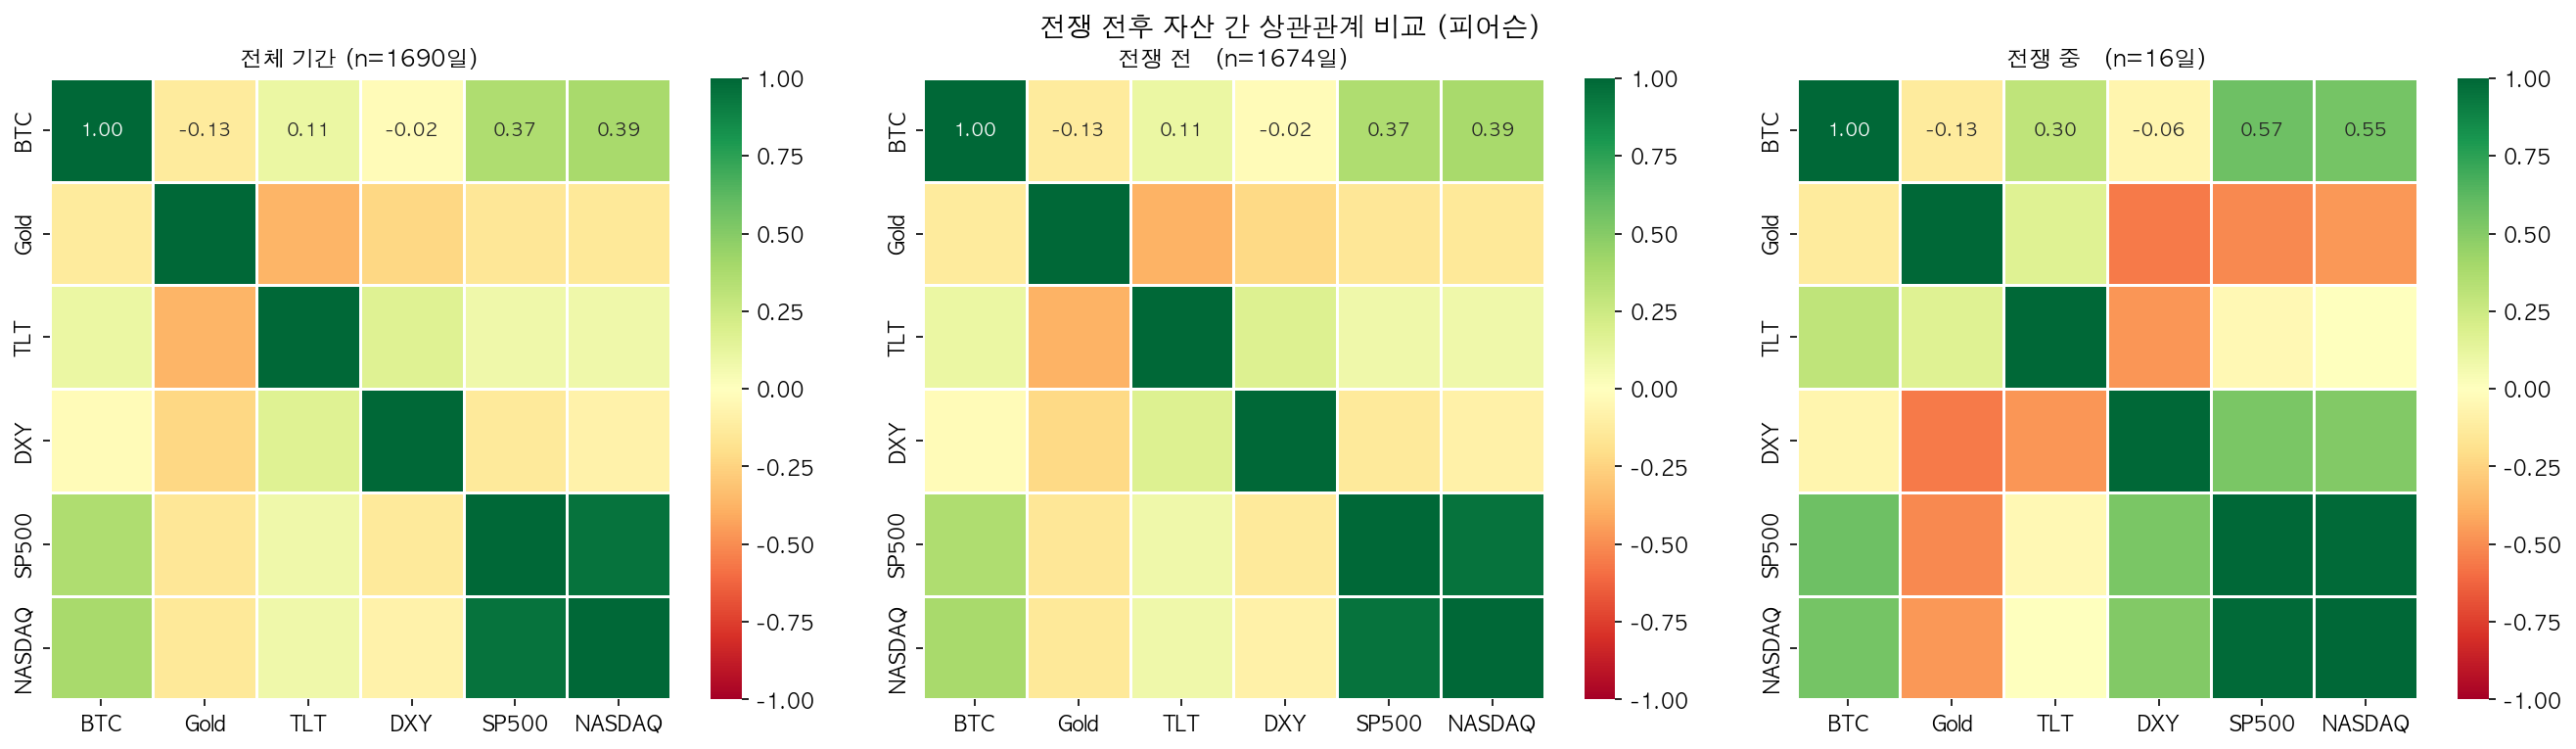

▶ plot6_corr_heatmap.png 저장


In [11]:
pre_war = returns[returns.index <  WAR_START]
war     = returns[returns.index >= WAR_START]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
datasets  = [
    (returns, f'전체 기간 (n={len(returns)}일)'),
    (pre_war, f'전쟁 전   (n={len(pre_war)}일)'),
    (war,     f'전쟁 중   (n={len(war)}일)'),
]

for ax, (data, title) in zip(axes, datasets):
    sns.heatmap(
        data.corr(method='pearson'),
        annot=True, fmt='.2f',
        cmap='RdYlGn', vmin=-1, vmax=1,
        ax=ax, square=True,
        linewidths=0.5, annot_kws={'size':9}
    )
    ax.set_title(title, fontsize=11, fontweight='bold')

fig.suptitle('전쟁 전후 자산 간 상관관계 비교 (피어슨)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot6_corr_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('▶ plot6_corr_heatmap.png 저장')

---
## Step 6-2. 이벤트별 ±60일 상관관계 히트맵


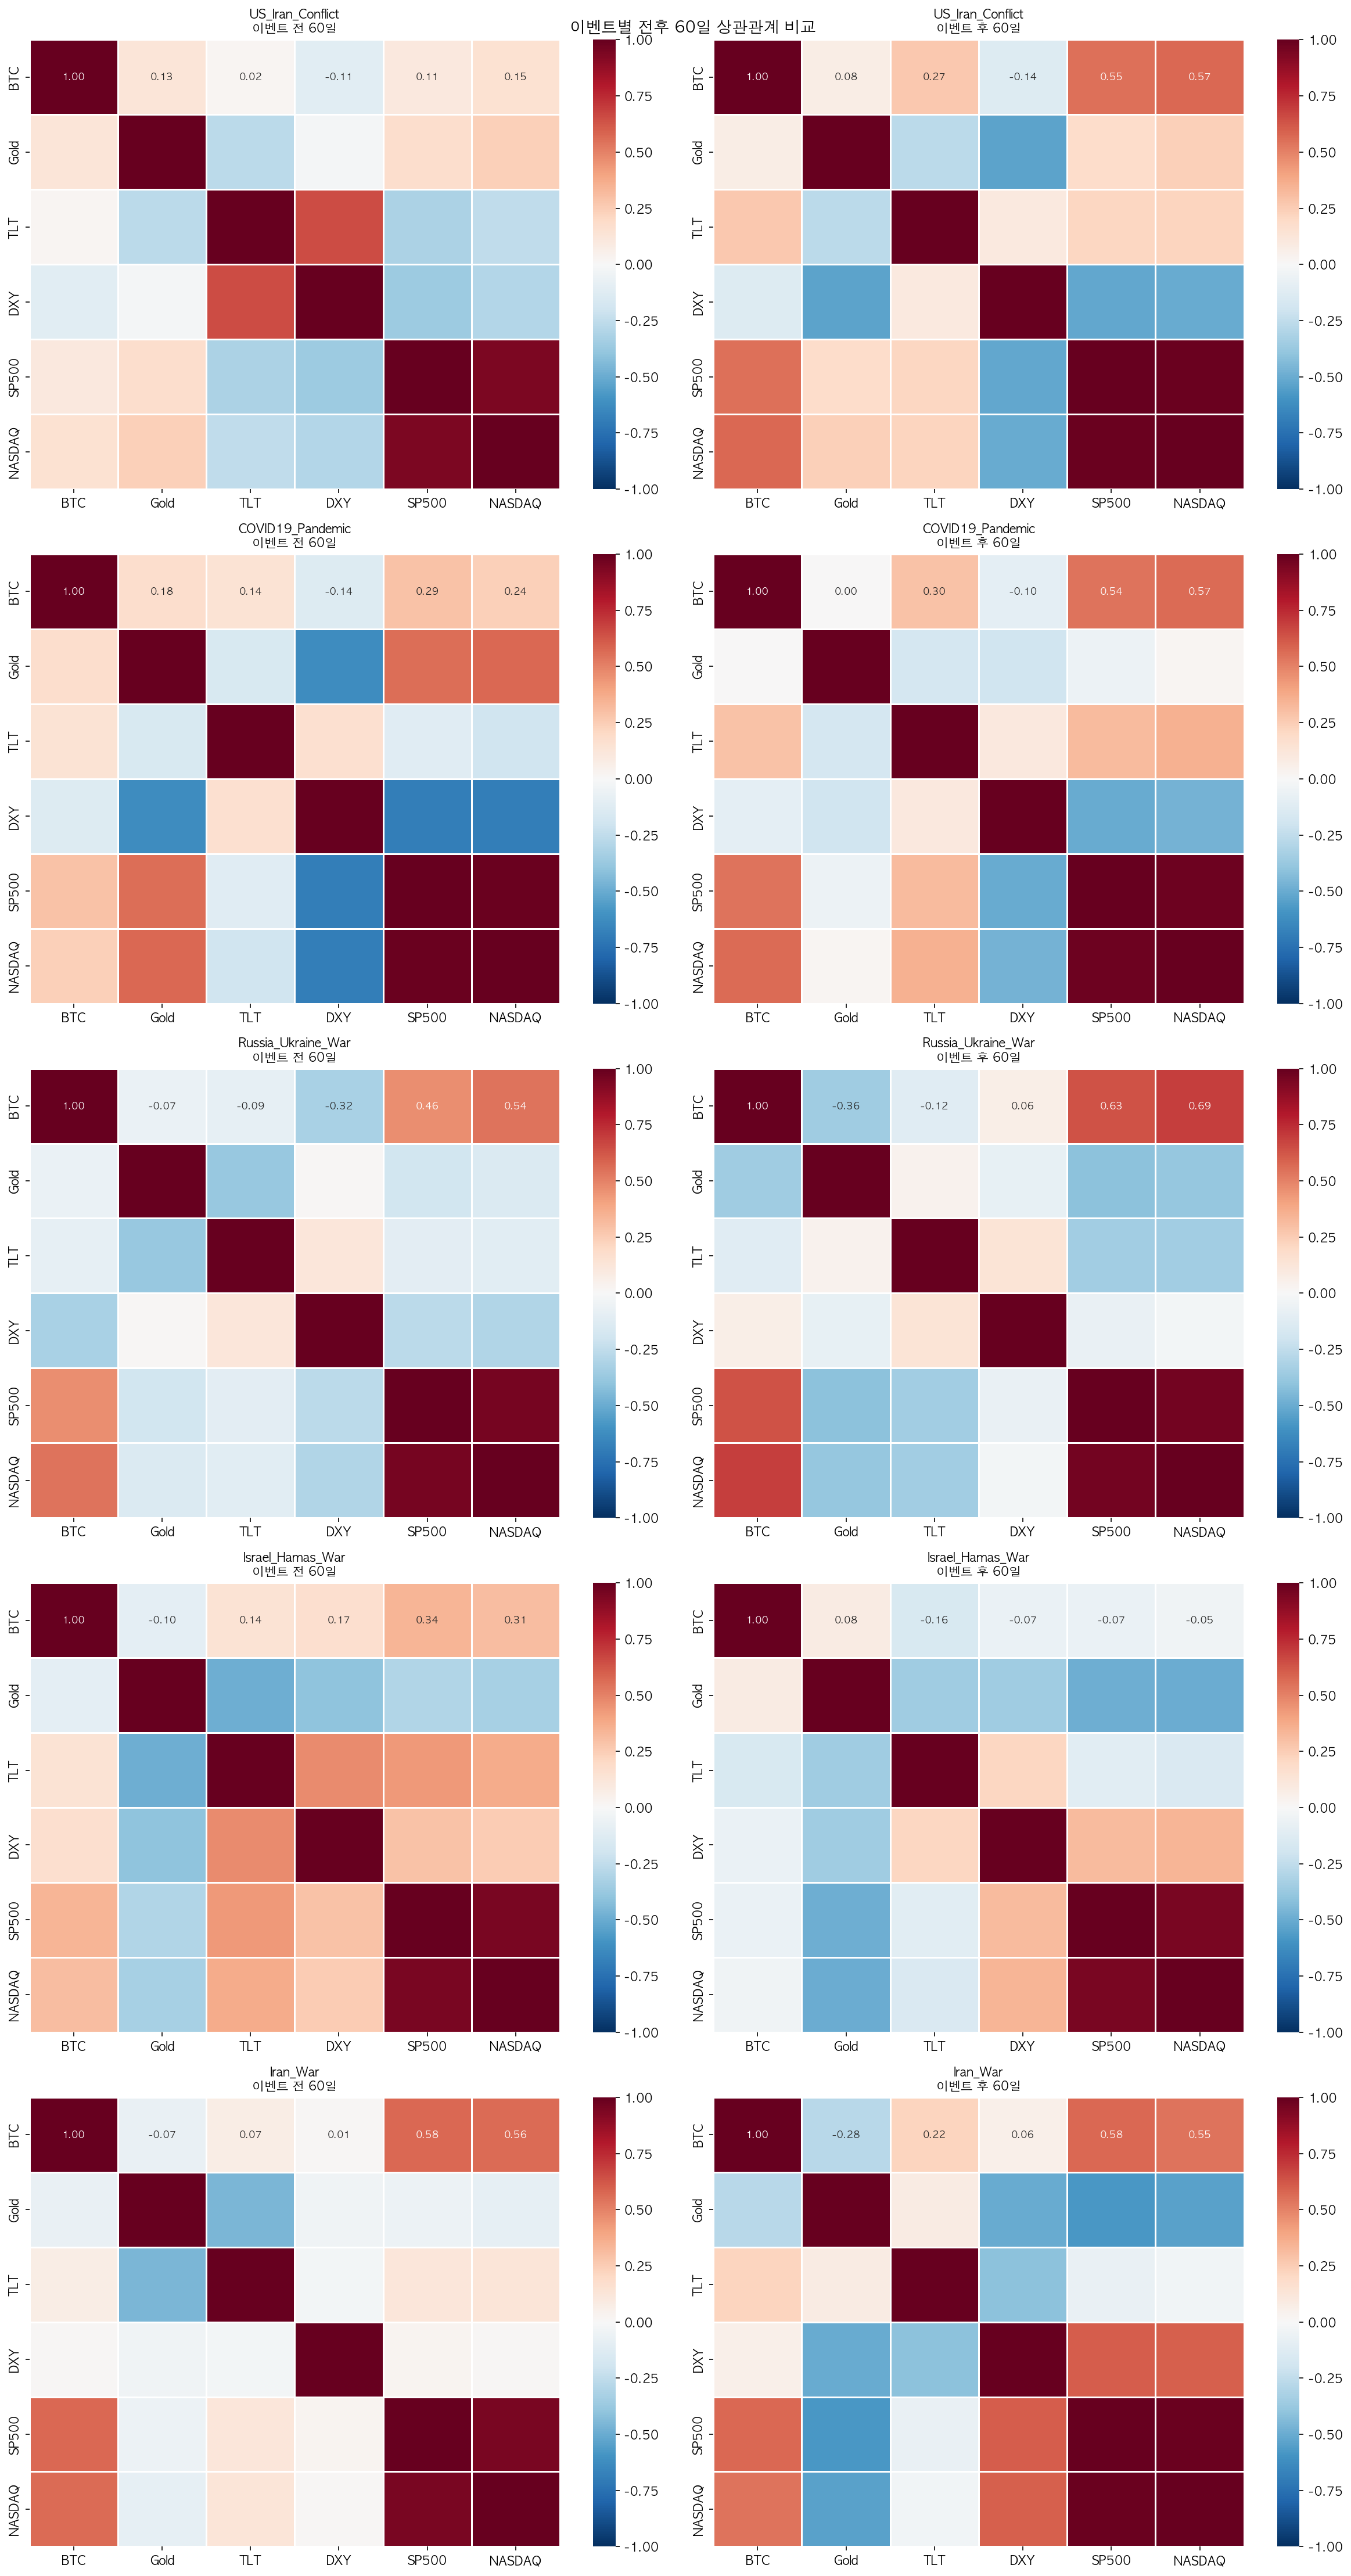

▶ plot7_event_heatmap.png 저장


In [12]:
fig, axes_grid = plt.subplots(
    len(EVENT_PERIODS), 2,
    figsize=(16, 6*len(EVENT_PERIODS))
)

for row_idx, (event_name, event_info) in enumerate(EVENT_PERIODS.items()):
    data       = get_event_data(event_name, event_info)
    event_date = data['event_date']
    close_df   = data['event_close']

    # 이벤트 전 60일 / 후 60일
    before_df = close_df[close_df.index <  event_date].tail(60)
    after_df  = close_df[close_df.index >= event_date].head(60)

    if len(before_df) < 5 or len(after_df) < 5:
        continue

    corr_before = np.log(before_df/before_df.shift(1)).dropna().corr()
    corr_after  = np.log(after_df /after_df.shift(1)).dropna().corr()

    ax1, ax2 = axes_grid[row_idx]

    sns.heatmap(corr_before, annot=True, fmt='.2f',
                cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                ax=ax1, linewidths=0.5, annot_kws={'size':8})
    ax1.set_title(f'{event_name}\n이벤트 전 60일', fontsize=10, fontweight='bold')

    sns.heatmap(corr_after, annot=True, fmt='.2f',
                cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                ax=ax2, linewidths=0.5, annot_kws={'size':8})
    ax2.set_title(f'{event_name}\n이벤트 후 60일', fontsize=10, fontweight='bold')

fig.suptitle('이벤트별 전후 60일 상관관계 비교',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot7_event_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('▶ plot7_event_heatmap.png 저장')

---
## Step 6-3. 이벤트별 전후 평균 수익률 비교


In [13]:
print('▶ 이벤트별 전후 BTC 평균 수익률 비교:\n')

rows = []
for event_name, event_info in EVENT_PERIODS.items():
    data = get_event_data(event_name, event_info)
    br   = data['before_returns']['BTC'].mean() * 100
    ar   = data['after_returns']['BTC'].mean()  * 100
    rows.append({
        '이벤트'           : event_name,
        '이벤트 전 평균(%)' : round(br, 4),
        '이벤트 후 평균(%)' : round(ar, 4),
        '차이(%)'          : round(ar - br, 4),
        '방향'             : '↑ 상승' if ar > br else '↓ 하락',
    })

event_df = pd.DataFrame(rows).set_index('이벤트')
display(event_df)

print('\n▶ 이벤트별 전체 자산 전후 평균 수익률 비교:\n')
for event_name, event_info in EVENT_PERIODS.items():
    data = get_event_data(event_name, event_info)
    br   = data['before_returns'].mean() * 100
    ar   = data['after_returns'].mean()  * 100
    diff = (ar - br).sort_values(ascending=False)
    print(f'[{event_name}]')
    print(pd.DataFrame({
        '전 평균(%)': br.round(4),
        '후 평균(%)': ar.round(4),
        'Difference': diff.round(4)
    }).to_string())
    print()

▶ 이벤트별 전후 BTC 평균 수익률 비교:



,이벤트 전 평균(%),이벤트 후 평균(%),차이(%),방향
이벤트,,,,
US_Iran_Conflict,-0.3246,0.2228,0.5473,↑ 상승
COVID19_Pandemic,-0.1477,0.3396,0.4873,↑ 상승
Russia_Ukraine_War,-0.0870,-0.4310,-0.3441,↓ 하락
Israel_Hamas_War,-0.0145,0.7616,0.7761,↑ 상승
Iran_War,-0.2441,0.4601,0.7042,↑ 상승



▶ 이벤트별 전체 자산 전후 평균 수익률 비교:

[US_Iran_Conflict]
        전 평균(%)  후 평균(%)  Difference
BTC     -0.3246   0.2228      0.5473
DXY      0.0277   0.1410      0.1133
Gold     0.0001   0.0029      0.0028
NASDAQ   0.0911   0.0884     -0.0027
SP500    0.0738  -0.0356     -0.1094
TLT      0.0746   0.1209      0.0463

[COVID19_Pandemic]
        전 평균(%)  후 평균(%)  Difference
BTC     -0.1477   0.3396      0.4873
DXY      0.0751   0.0068     -0.0683
Gold    -0.0196  -0.0354     -0.0157
NASDAQ   0.0357   0.2937      0.2580
SP500   -0.0116   0.1654      0.1770
TLT      0.0673   0.1400      0.0727

[Russia_Ukraine_War]
        전 평균(%)  후 평균(%)  Difference
BTC     -0.0870  -0.4310     -0.3441
DXY     -0.0628  -0.1191     -0.0563
Gold     0.0299   0.0843      0.0545
NASDAQ  -0.0826  -0.0483      0.0343
SP500   -0.0275  -0.0235      0.0040
TLT      0.0363  -0.0700     -0.1063

[Israel_Hamas_War]
        전 평균(%)  후 평균(%)  Difference
BTC     -0.0145   0.7616      0.7761
DXY     -0.1744   0.0730      0.2474
Go

---
## Step 7. 롤링 상관관계 (30일)

- BTC vs S&P500: 상관↓ → 안전자산 신호
- BTC vs Gold: 상관↑ → 안전자산 신호
- BTC vs TLT: 상관↑ → 안전자산 신호


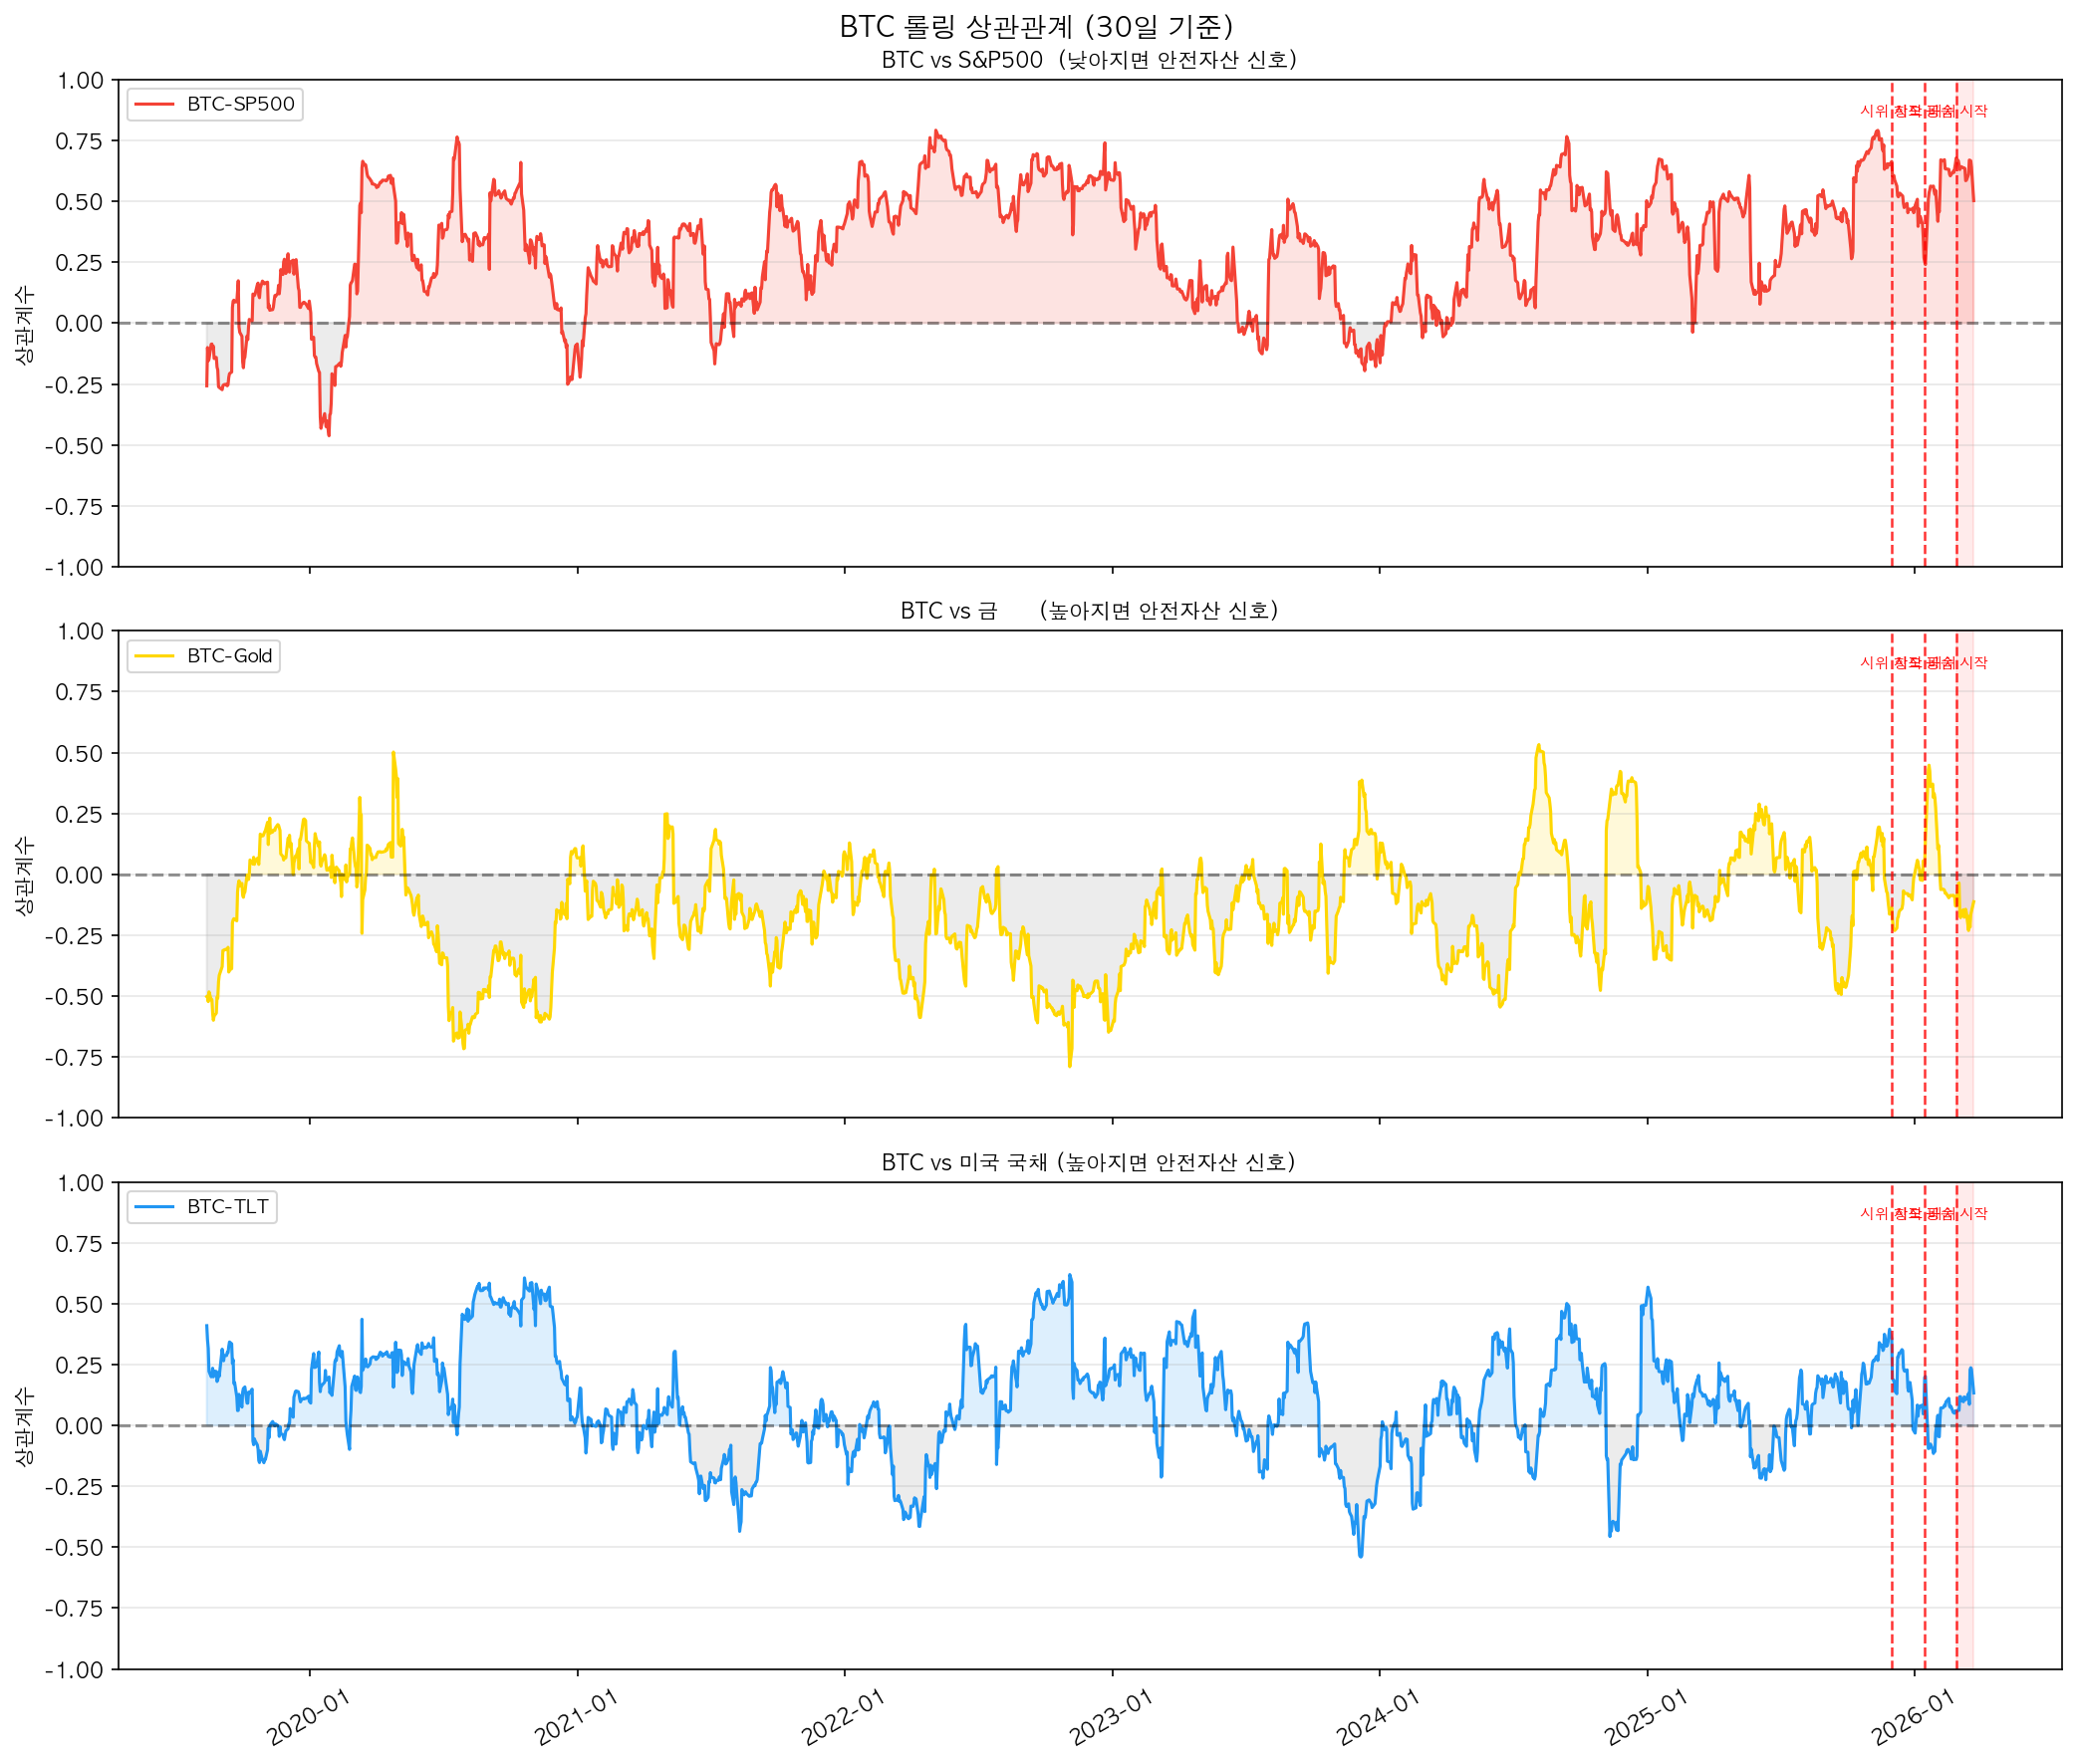

▶ plot8_rolling_corr.png 저장


In [14]:
WINDOW = 30
pairs  = [
    ('SP500', '#F44336', 'BTC vs S&P500  (낮아지면 안전자산 신호)'),
    ('Gold',  '#FFD700', 'BTC vs 금      (높아지면 안전자산 신호)'),
    ('TLT',   '#2196F3', 'BTC vs 미국 국채 (높아지면 안전자산 신호)'),
]

fig, axes = plt.subplots(len(pairs), 1,
                          figsize=(14, 4*len(pairs)), sharex=True)

for ax, (col, color, title) in zip(axes, pairs):
    rolling = returns['BTC'].rolling(WINDOW).corr(returns[col])
    ax.plot(rolling.index, rolling,
            color=color, linewidth=1.5, label=f'BTC-{col}')
    ax.axhline(0, color='black', linestyle='--', alpha=0.4)
    ax.fill_between(rolling.index, rolling, 0,
                    where=(rolling>0), alpha=0.15, color=color)
    ax.fill_between(rolling.index, rolling, 0,
                    where=(rolling<0), alpha=0.15, color='gray')

    for name, date in EVENTS.items():
        ts = pd.Timestamp(date)
        if ts >= returns.index.min():
            ax.axvline(ts, color='red', linestyle='--',
                       alpha=0.8, linewidth=1.2)
            ax.text(ts, 0.85, name.split('\n')[0],
                    fontsize=7, color='red', ha='center')

    war_ts = pd.Timestamp(WAR_START)
    if war_ts <= rolling.index.max():
        ax.axvspan(war_ts, rolling.index.max(),
                   alpha=0.08, color='red')

    ax.set_title(title, fontsize=10)
    ax.set_ylabel('상관계수')
    ax.set_ylim(-1, 1)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=9, loc='upper left')

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=30)
fig.suptitle(f'BTC 롤링 상관관계 ({WINDOW}일 기준)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot8_rolling_corr.png', dpi=150, bbox_inches='tight')
plt.show()
print('▶ plot8_rolling_corr.png 저장')

---
## Step 8. EDA 결과 요약


In [15]:
print('='*60)
print('EDA 결과 요약')
print('='*60)

print('\n▶ 변동성 비교 (연환산 %):')
vol = returns.std() * np.sqrt(252) * 100
for col in returns.columns:
    bar = '█' * int(vol[col] / 5)
    print(f'  {col:6s}: {vol[col]:5.1f}%  {bar}')

print('\n▶ 전쟁 전후 BTC 핵심 상관관계 변화 (피어슨):')
print(f'  {"자산":<8} {"전쟁 전":>8} {"전쟁 중":>8} {"변화":>8}  해석')
print('  ' + '-'*55)
for col in ['SP500','NASDAQ','Gold','TLT','DXY']:
    if col not in returns.columns: continue
    pre_c = pre_war.corr()['BTC'].get(col, float('nan'))
    war_c = war.corr()['BTC'].get(col, float('nan')) if len(war)>5 else float('nan')
    diff  = war_c - pre_c if not (pd.isna(pre_c) or pd.isna(war_c)) else float('nan')
    if col in ['SP500','NASDAQ']:
        sig = '✅ 안전자산 신호' if diff<-0.1 else ('❌ 위험자산 신호' if diff>0.1 else '→ 변화 미미')
    else:
        sig = '✅ 안전자산 신호' if diff>0.1  else ('❌ 위험자산 신호' if diff<-0.1 else '→ 변화 미미')
    print(f'  BTC-{col:<4} {pre_c:>8.3f} {war_c:>8.3f} {diff:>+8.3f}  {sig}')

print('\n▶ 산출물 목록:')
for f in ['plot1_price_trend','plot2_event_price','plot3_moving_average',
          'plot4_returns_dist','plot5_btc_highlow','plot6_corr_heatmap',
          'plot7_event_heatmap','plot8_rolling_corr']:
    print(f'  {f}.png')

# print('\n▶ 다음 단계:')
# print('  → Part 2: GPR 지수 산출 (뉴스 크롤링 + 감성 분석)')
# print('  → Part 3: 이벤트 스터디 (CAR 분석)')
# print('  → Part 4: GARCH-X 모델 (외생변수 = GPR 지수)')

EDA 결과 요약

▶ 변동성 비교 (연환산 %):
  BTC   :  62.6%  ████████████
  Gold  :   6.9%  █
  TLT   :  18.1%  ███
  DXY   :  16.7%  ███
  SP500 :  20.2%  ████
  NASDAQ:  24.5%  ████

▶ 전쟁 전후 BTC 핵심 상관관계 변화 (피어슨):
  자산           전쟁 전     전쟁 중       변화  해석
  -------------------------------------------------------
  BTC-SP500    0.365    0.572   +0.206  ❌ 위험자산 신호
  BTC-NASDAQ    0.388    0.552   +0.164  ❌ 위험자산 신호
  BTC-Gold   -0.130   -0.129   +0.001  → 변화 미미
  BTC-TLT     0.106    0.297   +0.191  ✅ 안전자산 신호
  BTC-DXY    -0.024   -0.065   -0.041  → 변화 미미

▶ 산출물 목록:
  plot1_price_trend.png
  plot2_event_price.png
  plot3_moving_average.png
  plot4_returns_dist.png
  plot5_btc_highlow.png
  plot6_corr_heatmap.png
  plot7_event_heatmap.png
  plot8_rolling_corr.png
